In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, TensorDataset

In [3]:
def get_data():    
    mnist_train = datasets.MNIST(root="./data", train=True, download=True)
    mnist_test = datasets.MNIST(root="./data", train=False, download=True)

    # We don't need labels for autoencoders, so we will just use the images as both inputs and targets
    X_train = mnist_train.data.float() / 255.0
    #y_train = mnist_train.targets.long()
    X_test = mnist_test.data.float() / 255.0
    #y_test = mnist_test.targets.long()

    X = torch.cat([X_train, X_test], dim=0)

    return X

In [4]:
class MNIST_Autoencoder(nn.Module):
    def __init__(self, encoding_dim=250, bottleneck_dim=50):
        super().__init__()
        self.fc1 = nn.Linear(28*28, encoding_dim) # first layer
        self.fc2 = nn.Linear(encoding_dim, bottleneck_dim) # encoder layer (bottleneck)
        self.fc3 = nn.Linear(bottleneck_dim, encoding_dim) # decoder layer (same size as encoder)  
        self.fc4 = nn.Linear(encoding_dim, 28*28)  # output layer (same size as input)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = torch.sigmoid(self.fc4(x)) # we use sigmoid to get outputs between 0 and 1, since the input images are normalized to [0, 1]
        return x 
    
# By using np.random.choice(..., replace=False) inside every iteration of the loop, we're treating the dataset as a giant pool where any image
#  could appear in any update step. This is a more "pure" form of stochastic sampling, even if it means some images might be seen twice in an 
# "epoch" and others not at all.

# The Advantage: If you have a massive dataset, you might not want to wait for a full "epoch" to finish. Manual sampling allows you to simply say,
#  "Train for 50,000 steps," without worrying about where an epoch starts or ends. It turns training into a continuous stream.

def train_autoencoder(model, X, optimizer, loss_fn, epochs):
    
    losses = np.zeros(epochs)

    for epoch in range(epochs):
        model.train()

        # select a random batch of images
        randomidx = np.random.choice(X.shape[0], size=32, replace=False) # random minibatch of 32 images
        X_batch = X[randomidx]

        output = model(X_batch)
        loss = loss_fn(output, X_batch.flatten(start_dim=1)) # we use the same images as both inputs and targets

        # backpropagation and optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # losses in this epoch
        losses[epoch] = loss.item()

    return losses

In [ ]:
learning_rate = 1e-3
epochs = 10000 # we set a lot of epochs since we are using small minibatches inside the training loop, so it is not so expensive in reality

model = MNIST_Autoencoder(encoding_dim=250, bottleneck_dim=50)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

X = get_data()
losses = train_autoencoder(model, X, optimizer, loss_fn, epochs)

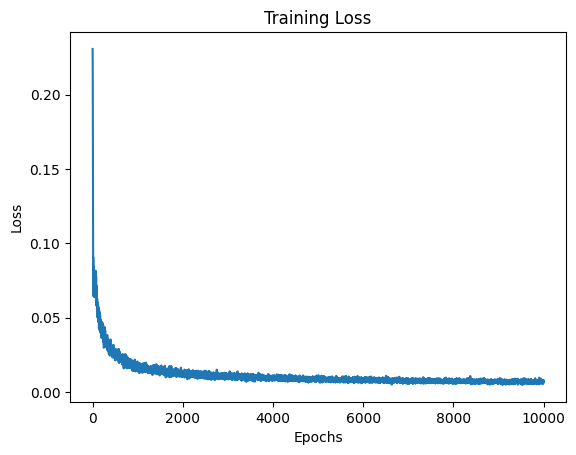

In [13]:
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

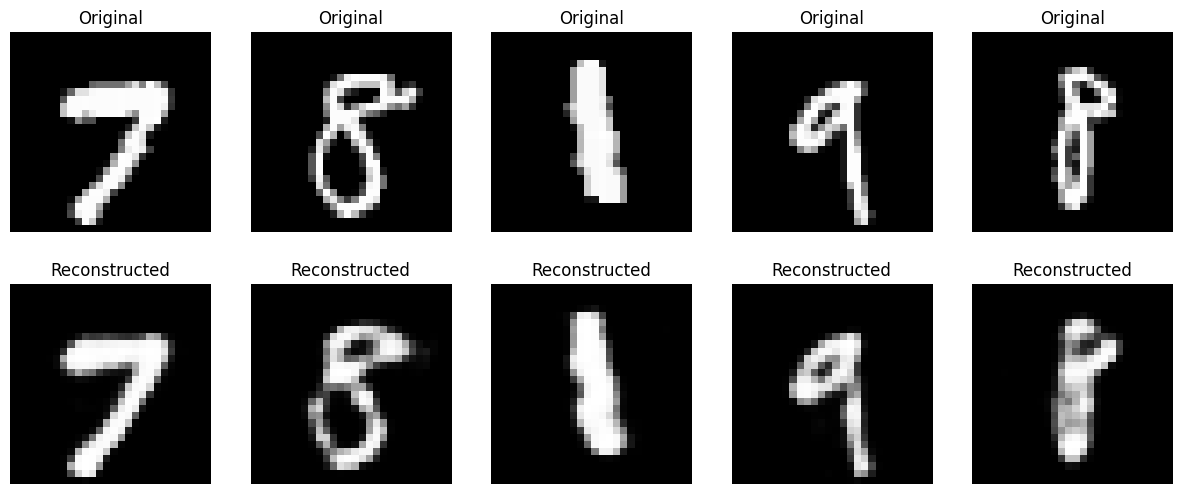

In [20]:
# After training, we can visualize some reconstructions to see how well the autoencoder is doing.
# Select a few random images from the dataset
randomidx = np.random.choice(X.shape[0], size=5, replace=False)
X_sample = X[randomidx]
with torch.no_grad():
    reconstructed = model(X_sample).cpu().numpy() # get reconstructions and move to CPU if needed

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # Original image
    axes[0, i].imshow(X_sample[i].cpu().numpy(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    
    # Reconstructed image (reshape back to 28x28)
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

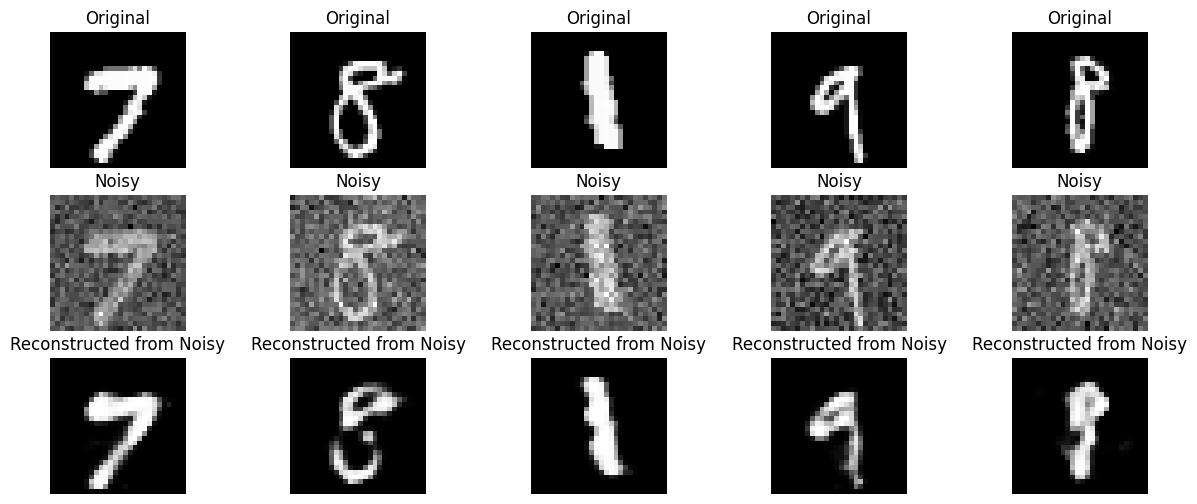

In [ ]:
# add noise to the original images and see how the autoencoder reconstructs them
noise = torch.randn_like(X_sample) * 0.25 # add Gaussian noise with std of 0.25
X_noisy = X_sample + noise

with torch.no_grad():
    reconstructed_noisy = model(X_noisy).cpu().numpy() # get reconstructions of noisy images

# Plot noisy and reconstructed images
fig, axes = plt.subplots(3, 5, figsize=(15, 6))
for i in range(5):
    # Original image
    axes[0, i].imshow(X_sample[i].cpu().numpy(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    # Noisy image
    axes[1, i].imshow(X_noisy[i].cpu().numpy(), cmap='gray')
    axes[1, i].set_title('Noisy')
    axes[1, i].axis('off')
    
    # Reconstructed image (reshape back to 28x28)
    axes[2, i].imshow(reconstructed_noisy[i].reshape(28, 28), cmap='gray')
    axes[2, i].set_title('Reconstructed from Noisy')
    axes[2, i].axis('off')

# Experiment with different sizes

In [7]:
def train_autoencoder2(model, X, optimizer, loss_fn, epochs):
    
    losses = np.zeros(epochs)
    batch_size = 32
    num_batches = X.shape[0] // batch_size

    # now each epoch goes through through all samples
    for epoch in range(epochs):
        model.train()

        # random permutation of the dataset at the start of each epoch to ensure we get different batches each time
        randomidx = np.random.permutation(X.shape[0]).astype(int)

        batch_losses = []

        for batch_i in range(num_batches):

            samps2use = range(batch_i*batch_size, (batch_i+1)*batch_size)
            X_batch = X[randomidx[samps2use]]

            output = model(X_batch)
            loss = loss_fn(output, X_batch.flatten(start_dim=1)) # we use the same images as both inputs and targets

            # backpropagation and optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
        
        # losses in this epoch
        losses[epoch] = np.mean(batch_losses)

    return losses

In [ ]:
encoding_units = np.linspace(10, 500, num=10, dtype=int) # different sizes for the encoding layer to test
bottle_neck_units = np.linspace(5, 100, num=8, dtype=int) # different sizes for the bottleneck layer to test
learning_rate = 1e-3
epochs = 3
X = get_data()
loss_fn = nn.MSELoss()

losses = np.zeros((len(encoding_units), len(bottle_neck_units))) # to store losses for each combination of hyperparameters

for enc_dim in encoding_units:
    for bottleneck_dim in bottle_neck_units:
        print(f"Training autoencoder with encoding_dim={enc_dim} and bottleneck_dim={bottleneck_dim}")
        model = MNIST_Autoencoder(encoding_dim=enc_dim, bottleneck_dim=bottleneck_dim)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
        temp_losses = train_autoencoder2(model, X, optimizer, loss_fn, epochs)
        losses[encoding_units == enc_dim, bottle_neck_units == bottleneck_dim] = np.mean(temp_losses[-3:])

Training autoencoder with encoding_dim=10 and bottleneck_dim=5
Training autoencoder with encoding_dim=10 and bottleneck_dim=18
Training autoencoder with encoding_dim=10 and bottleneck_dim=32
Training autoencoder with encoding_dim=10 and bottleneck_dim=45
Training autoencoder with encoding_dim=10 and bottleneck_dim=59
Training autoencoder with encoding_dim=10 and bottleneck_dim=72
Training autoencoder with encoding_dim=10 and bottleneck_dim=86
Training autoencoder with encoding_dim=10 and bottleneck_dim=100
Training autoencoder with encoding_dim=64 and bottleneck_dim=5


In [ ]:
# show the resuls matrix as a heatmap
plt.figure(figsize=(10, 8))
plt.imshow(losses, cmap='viridis', aspect='auto', vmin=0.01, vmax=0.05)
plt.colorbar(label='Loss')
plt.xlabel('Bottleneck Units')
plt.ylabel('Encoding Units')
plt.title('Loss for different encoding and bottleneck sizes')
plt.show()

# the less compression on the data, the better the reconstructions, so the best results are in the top right corner of the heatmap, 
# where we have more encoding units and more bottleneck units. However, this also means the model is more complex and has more parameters, 
# so it might be more prone to overfitting and less efficient.

# We can see it is like a smooth gradient, so there is no correct answer for the best hyperparameters, it depends on the trade-off we want 
# between reconstruction quality and model complexity.